In [1]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from sklearn.datasets import make_s_curve, make_blobs
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers



from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import *



from morbius import make_mobius_strip
from checker import make_nd_checkerboard
rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

/home/kenn50/miniconda3/envs/wsl-test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
E0502 15:58:21.716481   10799 cuda_executor.cc:1743] Could not get kernel mode driver version: [INVALID_ARGUMENT: Version does not match the format X.Y.Z]
E0502 15:58:21.732534   10683 cuda_executor.cc:1743] Could not get kernel mode driver version: [INVALID_ARGUMENT: Version does not match the format X.Y.Z]


In [3]:
def plot3d(d, title):
    d = d.reshape(-1, 3)
    fig = px.scatter_3d(x=d[:,0], y=d[:,1], z=d[:,2], title=title)
    fig.update_traces(marker=dict(size=2))


    fig.update_layout(
        title_text=title,
        title_x=0.5,              
        title_y=0.95,               
        title_font_family="Arial",  
        title_font_size=24,        
        title_font_color="navy",     
        margin=dict(t=60)            
    )

    fig.show()


In [4]:

X_3d_checkerboard = make_nd_checkerboard(2000, grid_shape=(4, 4, 1))[0]

plot3d(X_3d_checkerboard, "Checkerboard")

In [5]:
import numpy as np

n_samples = 2000

X_mobius, _  = make_mobius_strip(n_samples=2000, radius = 2, width = 3, noise=0.2)

plot3d(X_mobius, "Möbius Strip")

In [6]:
X_S, t = make_s_curve(noise=0.10, random_state=0, n_samples=1000)
plot3d(X_S, "Curve Data")

In [7]:
X_blobs, _=  make_blobs(centers=2,n_features=3, cluster_std=0.5, random_state=0, n_samples=1000)
plot3d(X_blobs, "Blob Data")

# Basic VAE

In [8]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )




def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )



def mean_network(hidden_dim, m_dim):
    SafeSoftplus = stax.elementwise(lambda x: jnp.log(1 + jnp.exp(x - 3.0)) + 1e-5)
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(m_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(m_dim, W_init=stax.randn()), SafeSoftplus),
        ),
    )



In [ ]:
X = X_blobs

batch_size = X.shape[0]
dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]

out_dim = X.reshape(X.shape[0], -1).shape[1]

hidden_dim = 8
z_dim = 2
lr=5e-3
adam = optim.Adam(lr)


encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}
mean_network_args = {"hidden_dim": hidden_dim, "m_dim": z_dim}

In [10]:
def plot_vae(vae, rng_key, share_axis=True):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    X_recon = vae.decode_latent({"z": values["z"]}, d_sub)

    has_m = values.get("m") is not None
    c_recon = values.get("pidx")

    plot3d(X_recon["obs"], "recon")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=share_axis, sharey=share_axis)

    for ax in axes.flat:
        ax.set_aspect('equal')

    axes[0, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_recon)
    axes[0, 0].set_title("recon latent (z)")

    if has_m:
        axes[0, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_recon)
        axes[0, 1].set_title("recon latent (m)")
    else:
        axes[0, 1].axis("off")

    values = vae.sample(s_sub, 1000)
    plot3d(values["obs"], "samples")

    c_samp = values.get("pidx")

    axes[1, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_samp)
    axes[1, 0].set_title("samples latent (z)")

    if has_m:
        axes[1, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_samp)
        axes[1, 1].set_title("samples latent (m)")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

# SMIVAE74

In [11]:
def plot_smi_vae(vae, rng_key):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    X_recon = vae.decode_latent({key:value  for key, value in values.items() if "z" in key}, d_sub, size_site="z0")

    plot3d(X_recon["obs"], "recon")


    values = vae.sample(s_sub, 3000)
    plot3d(values["obs"], "samples")


In [12]:
def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
    )

def g(z_dim):
    return stax.serial(
        stax.Dense(z_dim, W_init=stax.randn()),
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
    )

In [13]:
rng_key, sub_key = jax.random.split(rng_key)
f_args = {"hidden_dim": hidden_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim}
h_args = {"hidden_dim": hidden_dim, "h_dim": z_dim}
flow_args = {"input_dim": z_dim, "hidden_dims": [5, 5], "steps": 10, "inv": True}
smivae74 = SMIVAE74(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, 4, z_dim, normalizing_flow, flow_args)
smivae74.train(dataloader, len(X), adam, num_epochs=4000, rng_key=sub_key, num_stein_particles=5, annealing_epochs=1) # Annealing disabled

TypeError: VAE74.__init__() missing 1 required positional argument: 'flow_args'

In [ ]:
rng_key, sub_key = jax.random.split(rng_key)
plot_smi_vae(smivae74, sub_key)

# Post hoc model


In [16]:
rng_key, sub_key = jax.random.split(rng_key)
hoc_vae = PostHocSteinVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

hoc_vae.train(dataloader, X.shape[0], adam, 6500, sub_key, num_stein_particles=8, post_hoc_epochs=5000)




100%|██████████| 5000/5000 [00:17<00:00, 281.25it/s] 


In [17]:
hoc_vae.post_hoc_params["B"]

Array([[0.18574066, 0.13338964],
       [0.18632962, 0.14097351],
       [0.18682897, 0.13422918],
       [0.18642594, 0.13336194],
       [0.18617876, 0.14470342],
       [0.18636961, 0.1386104 ],
       [0.18652697, 0.1366693 ],
       [0.18754676, 0.14078698]], dtype=float32)

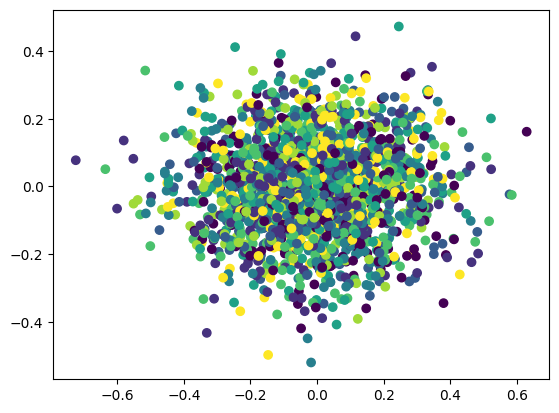

In [18]:
rng_key, sub_key = jax.random.split(rng_key)
results = hoc_vae.get_post_hoc_samples(sub_key, 2000)
plt.scatter(results["z"][:, 0], results["z"][:, 1], c=results.get("zidx"))

In [19]:
# decode resutls to see if they look good
decode_results=hoc_vae.decode_latent(results, sub_key)["obs"]
fig = px.scatter_3d(x=decode_results[:,0], y=decode_results[:,1], z=decode_results[:,2], title="decoded samples")
fig.update_traces(marker=dict(size=2))

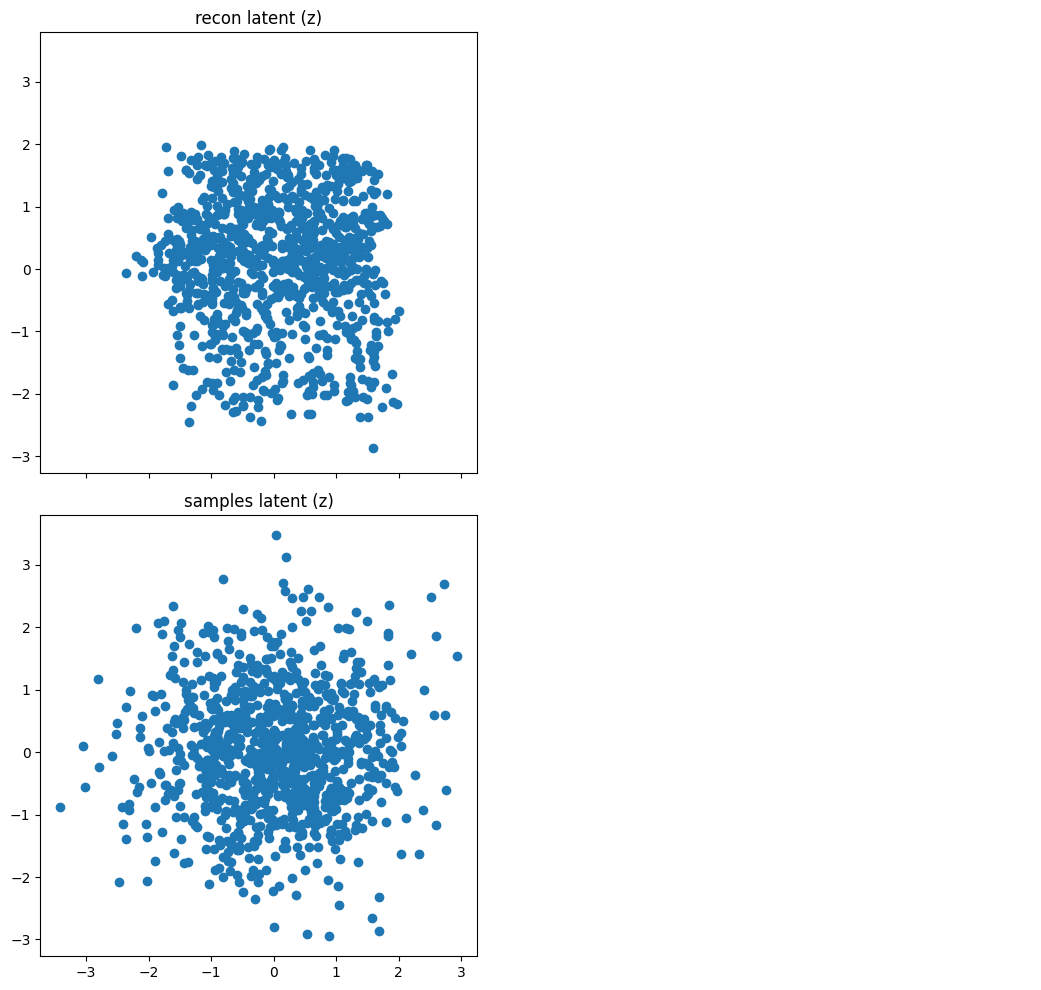

In [20]:
plot_vae(hoc_vae, sub_key)

# Just a model flow

In [25]:
rng_key, sub_key = jax.random.split(rng_key)
flow_args = {"input_dim": z_dim, "hidden_dims": [5, 5], "steps": 10, "inv": True}
base_vae = FlowBasicVAE(encoder, encoder_args, decoder, decoder_args, z_dim, normalizing_flow, flow_args)

base_vae.train(dataloader, X.shape[0], adam, 10000, sub_key, annealing_epochs=1000)




100%|██████████| 10000/10000 [01:07<00:00, 147.67it/s]


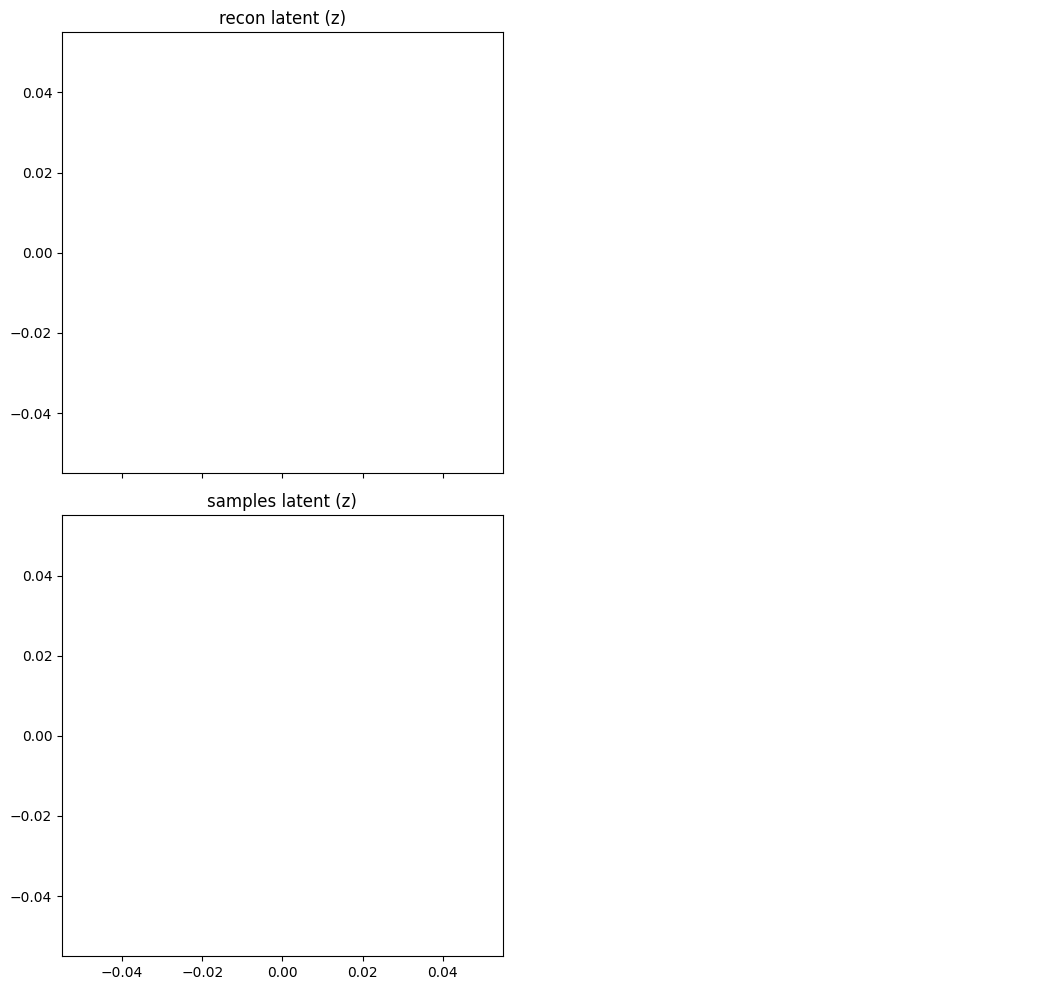

In [26]:
plot_vae(base_vae, sub_key)

# A global Parameter


In [27]:
rng_key, sub_key = jax.random.split(rng_key)

global_vae = GlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)




100%|██████████| 10000/10000 [00:11<00:00, 895.66it/s]


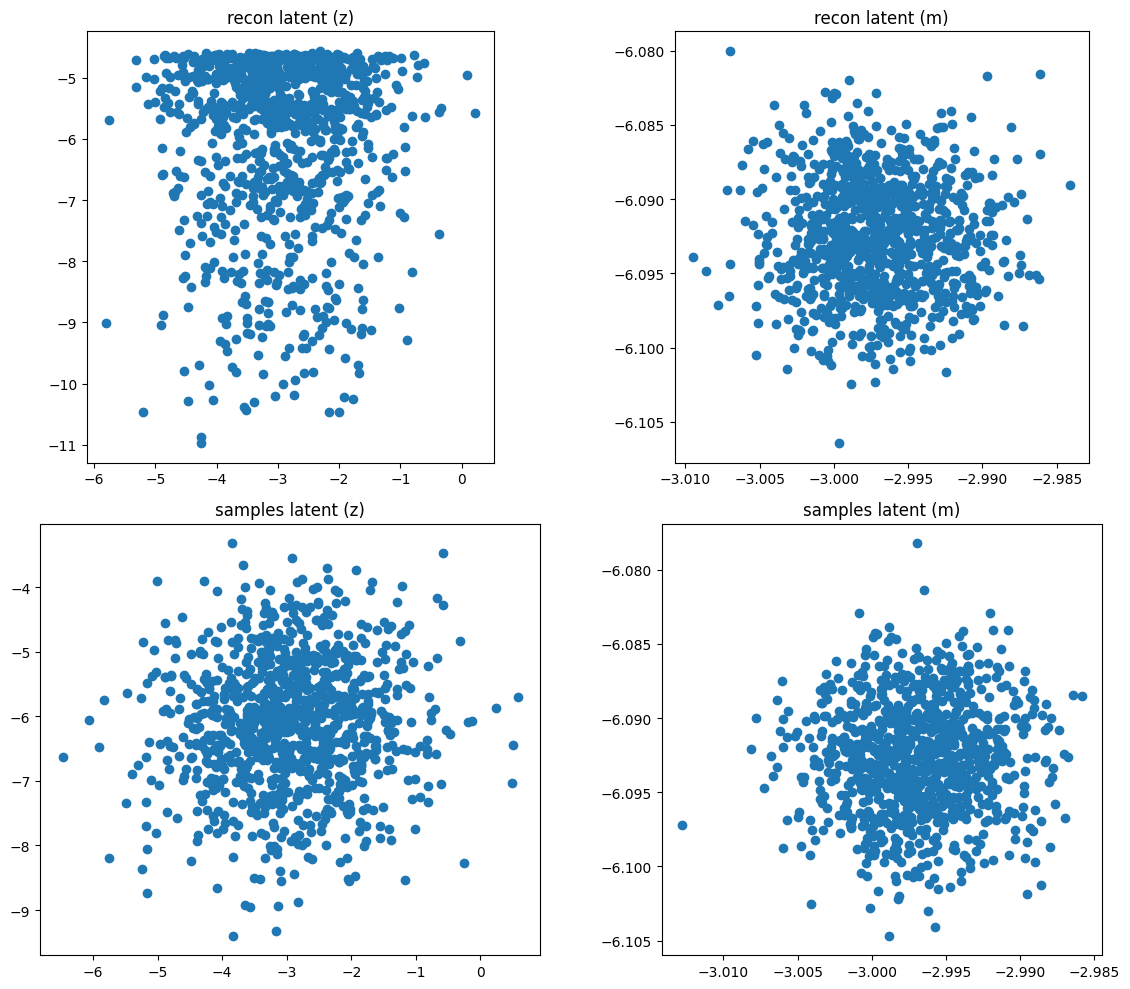

In [28]:
plot_vae(global_vae, sub_key, False)

# Stein global

In [29]:
rng_key, sub_key = jax.random.split(rng_key)

stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

stein_global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key, 5, repulsion_temperature=1)




  0%|          | 0/10000 [00:00<?, ?it/s]E0502 16:08:04.104793   10808 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0502 16:08:04.256239   10812 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
Epoch 9999, Loss: 14.50: 100%|██████████| 10000/10000 [01:25<00:00, 117.03it/s]


Ran with 10000 batches


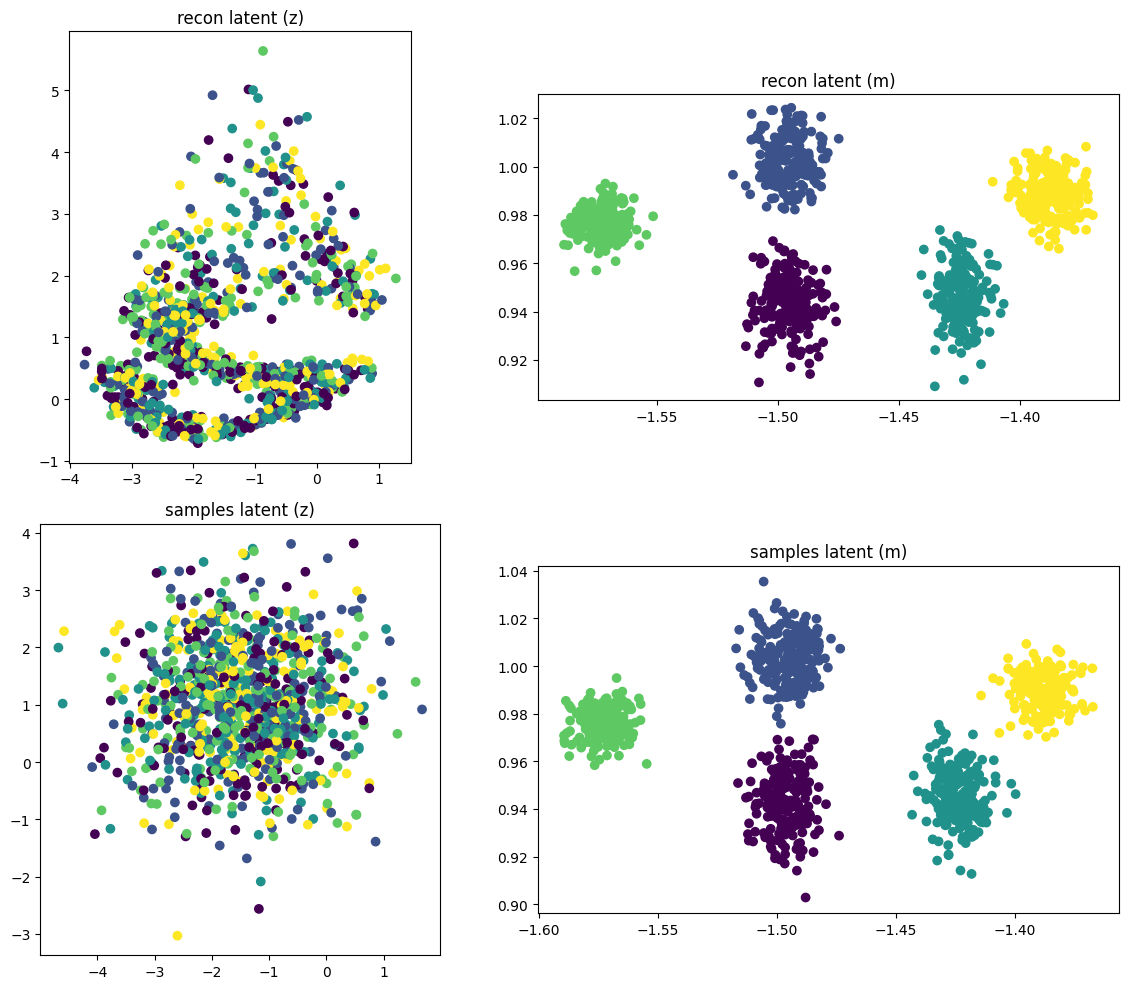

In [30]:
plot_vae(stein_global_vae, sub_key, False)

# Guide Flow


In [31]:
rng_key, sub_key = jax.random.split(rng_key)


flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 10, "inv": True}

guide_flow_vae = GuideFlowGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

guide_flow_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)



100%|██████████| 10000/10000 [00:26<00:00, 372.49it/s]


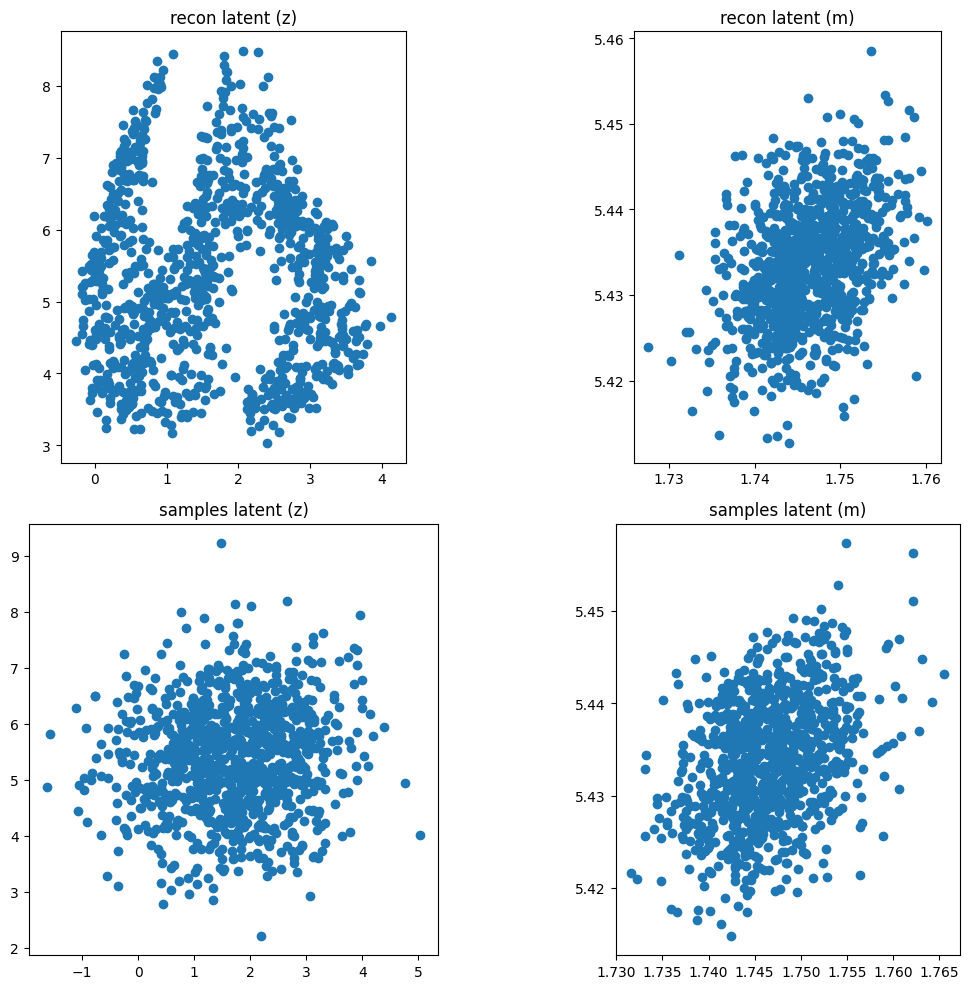

In [32]:
plot_vae(guide_flow_vae, sub_key, False)

# STEIN GUIDE FLOW

In [33]:
rng_key, sub_key = jax.random.split(rng_key)
clipped_adam = optim.ClippedAdam(lr, 10)

flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": True}

stein_guide_flow_vae = SteinGuideFlowVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

stein_guide_flow_vae.train(dataloader, X.shape[0], adam, 5000, sub_key, num_stein_particles=3, repulsion_temperature=1)



  0%|          | 0/5000 [00:00<?, ?it/s]E0502 16:10:11.029295   10821 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0502 16:10:11.773511   10807 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0502 16:10:11.898764   10818 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
Epoch 4999, Loss: 18.61: 100%|██████████| 5000/5000 [01:35<00:00, 52.10it/s]


Ran with 5000 batches


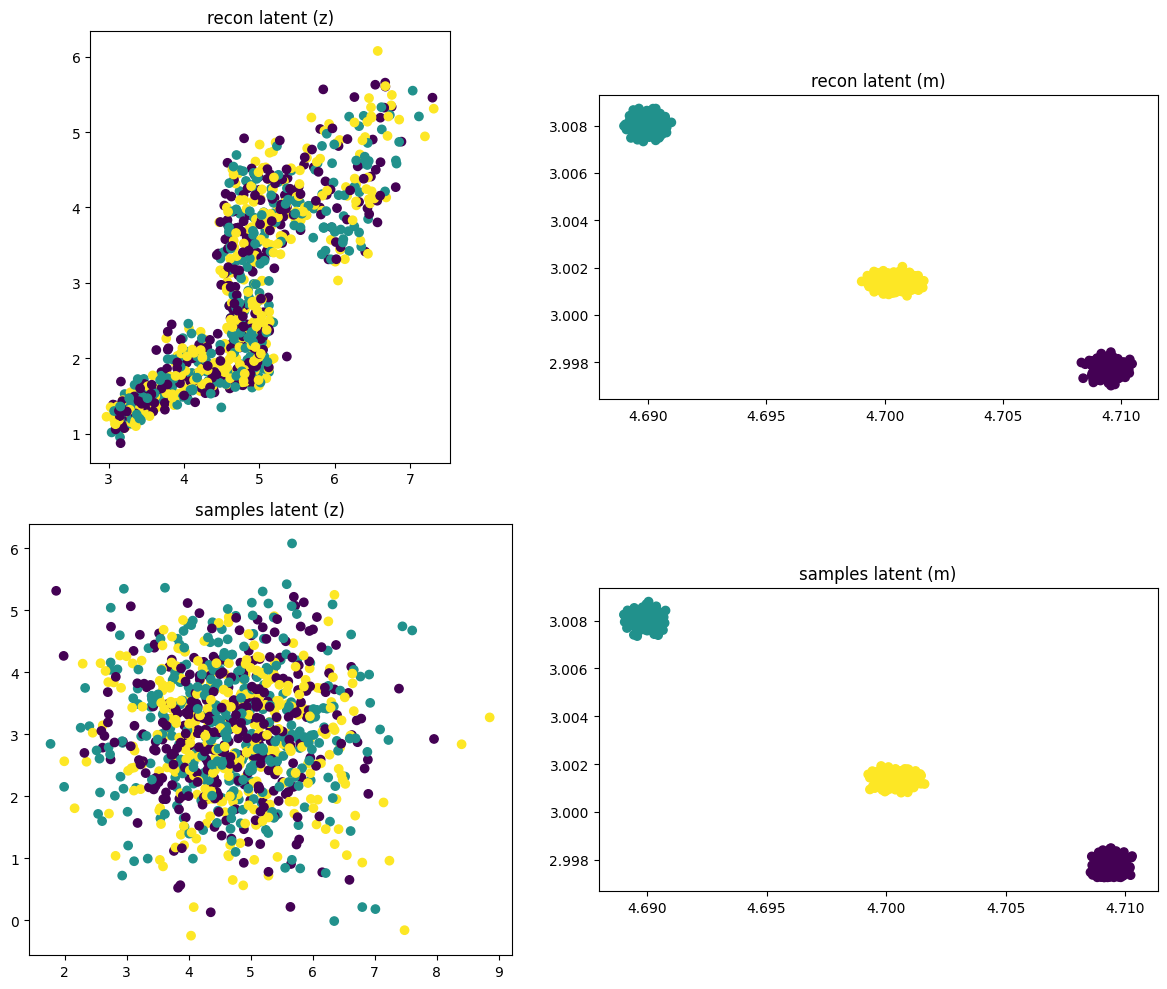

In [34]:
rng_key, sub_key = jax.random.split(rng_key)
plot_vae(stein_guide_flow_vae, sub_key, False)

# Learned Mean Stein

In [ ]:
rng_key, sub_key = jax.random.split(rng_key)

flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": True}

learned_mean_stein_guide_flow_vae = LearnedMeanSteinGuideFlowVAE(encoder, encoder_args, decoder, 
                                                    decoder_args, mean_network, mean_network_args, 
                                                    z_dim, flow=normalizing_flow, flow_args=flow_args)

learned_mean_stein_guide_flow_vae.train(dataloader, X.shape[0], optim.Adam(0.003), 6000, sub_key, num_stein_particles=3, repulsion_temperature=1, bandwidth_scaler=50)



Epoch 1649, Loss: nan:  26%|██▌       | 1560/6000 [00:50<23:00,  3.22it/s]            

NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan


Epoch 1661, Loss: nan:  26%|██▌       | 1560/6000 [00:51<23:00,  3.22it/s]

NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan


Epoch 1674, Loss: nan:  26%|██▌       | 1560/6000 [00:51<23:00,  3.22it/s]

...

NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan


Epoch 5989, Loss: nan:  98%|█████████▊| 5892/6000 [02:01<00:01, 61.31it/s]

NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan


Epoch 5999, Loss: nan: 100%|██████████| 6000/6000 [02:01<00:00, 49.46it/s]


NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
NaN detected in particle gradients!: nan
Ran with 6000 batches


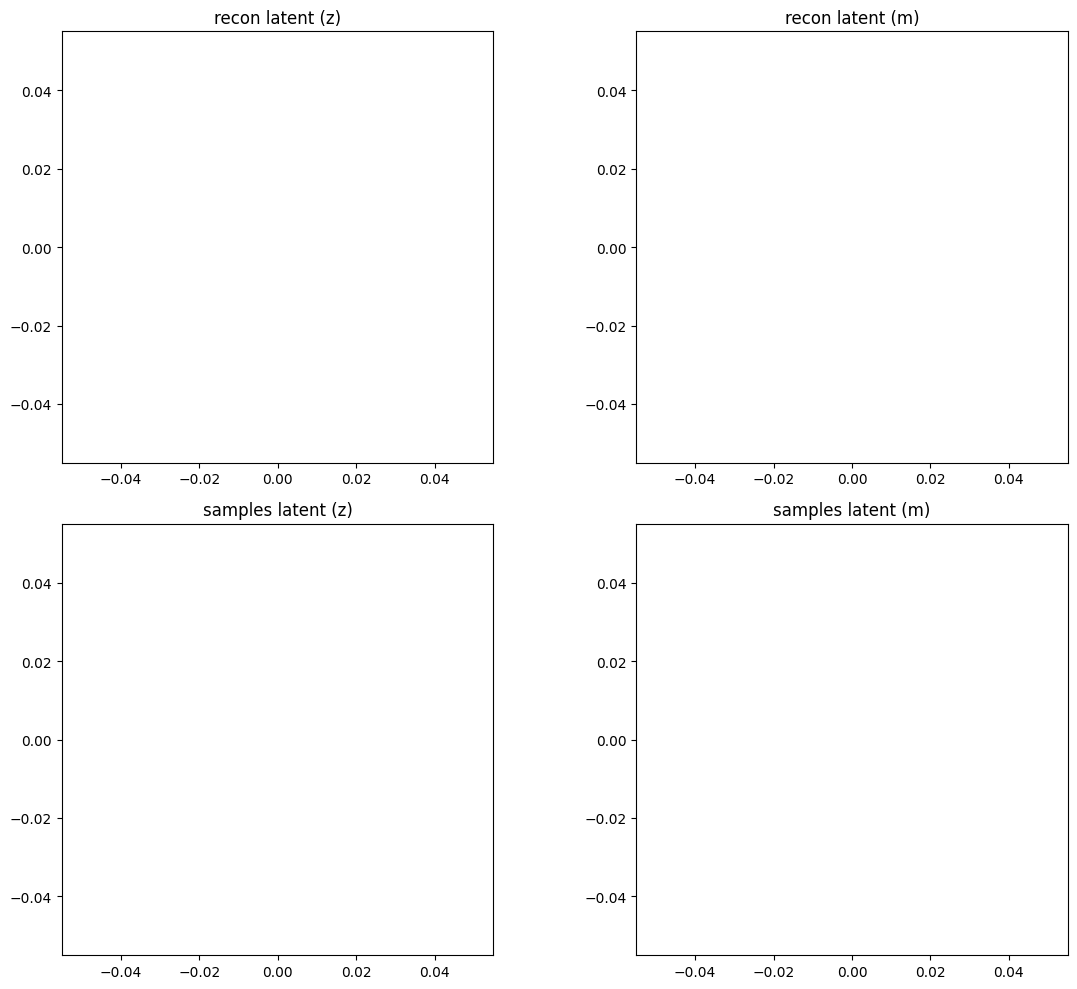

In [36]:
rng_key, sub_key = jax.random.split(rng_key)
plot_vae(learned_mean_stein_guide_flow_vae, sub_key, False)